# Import Dependencies

In [ ]:
import numpy as np
import os
import cv2
import pickle
import copy

In [ ]:
# Get module_dnn.py script from GitHub
!wget https://raw.githubusercontent.com/renelarsson/tensorflow_files/main/custom_dnn_module.py

import custom_dnn_module

--2024-09-17 14:07:56--  https://raw.githubusercontent.com/renelarsson/tensorflow_files/main/custom_dnn_module.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44034 (43K) [text/plain]
Saving to: ‘custom_dnn_module.py’

custom_dnn_module.p 100%[===================>]  43.00K  --.-KB/s    in 0.01s   

2024-09-17 14:07:56 (3.82 MB/s) - ‘custom_dnn_module.py’ saved [44034/44034]



In [ ]:
# Get classes from module
from custom_dnn_module import (DenseLayer, InputLayer, ReluActivation, SoftmaxActivation, AdamOptimizer,
                        CategoricalCrossentropyLoss, SoftmaxClassifier, ClassificationAccuracy, Model)

# Prepare the dataset


## Get the Data
The fashion mnist data has respectively 60000 and 10000 images in the train and test folders.

In [ ]:
# Connect to G-drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Retrieve the data
FILE = '/content/gdrive/MyDrive/Colab Notebooks/fashion_mnist_images.zip'
FOLDER = 'fashion_mnist_images'

In [ ]:
# Unzip the files
from zipfile import ZipFile

print('Unzipping images...')
with ZipFile(FILE) as zip_images:# open and close file
  zip_images.extractall(FOLDER)

print('Done!')

Unzipping images...
Done!


## Explore the Data

In [ ]:
# The subdirectory names are the labels
import os

labels = os.listdir('fashion_mnist_images/train')
print(labels)

['9', '4', '5', '8', '3', '1', '6', '0', '2', '7']


In [ ]:
# Inspect subdirectories
files = os.listdir('fashion_mnist_images/train/0')
print(files[:10])
print(len(files))

['4332.png', '5068.png', '3519.png', '3285.png', '1251.png', '4657.png', '4033.png', '2529.png', '0229.png', '1875.png']
6000


In [ ]:
# Load the image data and read them in their saved format (grayscale)
import cv2

image_data = cv2.imread('fashion_mnist_images/train/7/0002.png', cv2.IMREAD_UNCHANGED)

# Print entire character row per line
import numpy as np

np.set_printoptions(linewidth=200)
print(image_data)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0  49 135 182 150  59   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  78 255 220 21

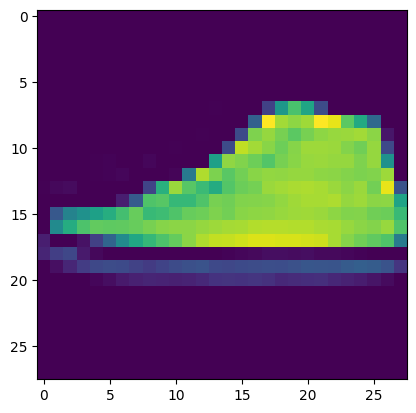

In [ ]:
# Visualize with matplotlib
import matplotlib.pyplot as plt

plt.imshow(image_data)
plt.show()

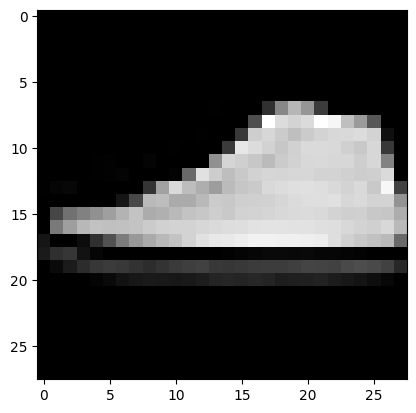

In [ ]:
# Plot in grayscale
image_data = cv2.imread('fashion_mnist_images/train/7/0002.png', cv2.IMREAD_UNCHANGED)
plt.imshow(image_data, cmap='gray')
plt.show()

## Load the Dataset

In [ ]:
# Load MNIST dataset
def load_mnist_dataset(dataset, path):

  # Create a list of labels from directory names (subdirectory names are the labels)
  labels = os.listdir(os.path.join(path, dataset))

  # Create lists for samples and labels
  X = []
  y = []

  # For each directory (label)
  for label in labels:
    # For each image in the directory
    for file in os.listdir(os.path.join(path, dataset, label)):
      # Read the image
      image = cv2.imread(os.path.join(path, dataset, label, file), cv2.IMREAD_UNCHANGED)

      # Append the image and a label to the lists
      X.append(image)
      y.append(label)

  # Convert lists numpy arrays (labels as integers not floats)
  return np.array(X), np.array(y).astype('uint8')

# Split and Preprocess the Data

Dense layers work on batches of 1-dimensional vectors, while the images
are shaped as a 28x28 (2-dimensional array) and need to be flattened to 1 dimension (28x28=784). Validation set created from training folder.

In [ ]:
def create_data_mnist(path):

  # Load both sets separately
  X, y = load_mnist_dataset('train', path)
  X_test, y_test = load_mnist_dataset('test', path)# get only from test path
  # Check data type, shape and scale
  print(X[0].dtype, y[0].dtype, X[0].shape, X.min(), X.max())

  # Shuffle the training data - added
  keys = np.array(range(X.shape[0]))# Get key values 0-59999 -> array([0 1 2 3 4 ...])
  print(keys[:10])
  np.random.shuffle(keys)# Shuffle keys
  print(keys[:10])
  # Order samples and labels by same key indecies
  X = X[keys]
  y = y[keys]

  # Calculate split index  - added
  split_index = int(len(X) * 0.8)  # 80% for training

  # Split into training and validation sets - added
  X, X_val = X[:split_index], X[split_index:]
  y, y_val = y[:split_index], y[split_index:]

  # Scale (-1 to 1) and reshape samples (60,000 samples (X.shape[0]) of 784 features each) - added
  X = (X.reshape(X.shape[0], -1).astype(np.float32) - 127.5) / 127.5
  X_val = (X_val.reshape(X_val.shape[0], -1).astype(np.float32) - 127.5) / 127.5 # added
  X_test = (X_test.reshape(X_test.shape[0], -1).astype(np.float32) - 127.5) / 127.5
  # Check data type, shape and scale
  print(X[0].dtype, y[0].dtype, X[0].shape, X.min(), X.max())

  # Return the data
  return X, y, X_val, y_val, X_test, y_test

In [ ]:
# Create dataset
X, y, X_val, y_val, X_test, y_test = create_data_mnist('fashion_mnist_images')

uint8 uint8 (28, 28) 0 255
[0 1 2 3 4 5 6 7 8 9]
[ 9485  3090 56860 20772  9728  6065 35477 26777  4819  8889]
float32 uint8 (784,) -1.0 1.0


# Create the Model

In [ ]:
# Instantiate the model
model = Model()

# Add layers
model.add(DenseLayer(X.shape[1], 128))# Get image shape (784)
model.add(ReluActivation())
model.add(DenseLayer(128, 128))
model.add(ReluActivation())
model.add(DenseLayer(128, 10))
model.add(SoftmaxActivation())

# Compile the Model

**NB: Change 'set' to 'compile' in VScode and GitHub**

In [ ]:
# Set loss, optimizer and accuracy objects
model.compile(loss=CategoricalCrossentropyLoss(),
              optimizer=AdamOptimizer(decay=1e-4),
              accuracy=ClassificationAccuracy())

# Train the Model

In [ ]:
# Finalize the model
model.finalize()
# Train the model
model.train(X, y,
            validation_data=(X_val, y_val),
            epochs=10,
            batch_size=128,
            print_every=100)

epoch: 1
step: 0, acc: 0.062, loss: 2.302 (data_loss: 2.302, reg_loss: 0.000), lr: 0.001
step: 100, acc: 0.797, loss: 0.524 (data_loss: 0.524, reg_loss: 0.000), lr: 0.0009900990099009901
step: 200, acc: 0.820, loss: 0.474 (data_loss: 0.474, reg_loss: 0.000), lr: 0.000980392156862745
step: 300, acc: 0.789, loss: 0.578 (data_loss: 0.578, reg_loss: 0.000), lr: 0.0009708737864077671
step: 374, acc: 0.898, loss: 0.372 (data_loss: 0.372, reg_loss: 0.000), lr: 0.0009639483323693849
training, acc: 0.743, loss: 0.688 (data_loss: 0.688, reg_loss: 0.000), lr: 0.0009639483323693849
validation, acc: 0.829, loss: 0.470
epoch: 2
step: 0, acc: 0.797, loss: 0.490 (data_loss: 0.490, reg_loss: 0.000), lr: 0.0009638554216867469
step: 100, acc: 0.883, loss: 0.328 (data_loss: 0.328, reg_loss: 0.000), lr: 0.000954653937947494
step: 200, acc: 0.898, loss: 0.296 (data_loss: 0.296, reg_loss: 0.000), lr: 0.0009456264775413711
step: 300, acc: 0.836, loss: 0.513 (data_loss: 0.513, reg_loss: 0.000), lr: 0.000936768

#Evaluate the Model
Evaluate the model either during training or on-demand, by passing the validation or testing data. In the former, to monitor the model's performance on unseen data during the training process. This helps to detect overfitting (where the model performs well on training data but poorly on new data) and to tune hyperparameters (e.g., learning rate, regularization strength). In the latter, to obtain a final, unbiased estimate of the model's performance on completely unseen data after the training process is complete.

In [ ]:
model.evaluate(X_test, y_test)

validation, acc: 0.874, loss: 0.353


## Get and Set Parameters

In [ ]:
# Retrieve and print parameters
parameters = model.get_parameters()
print(parameters)

[(array([[ 0.03914766,  0.00051102, -0.00223864, ...,  0.0456848 ,  0.01432701,  0.01713113],
       [ 0.05897002, -0.00395828, -0.03087202, ...,  0.04309433,  0.00382943, -0.00506715],
       [ 0.05268177,  0.00575167, -0.01024964, ...,  0.04100431,  0.02453078,  0.01446361],
       ...,
       [ 0.04979925,  0.04079302,  0.01273687, ...,  0.0568753 ,  0.00908473, -0.00066576],
       [ 0.04199679,  0.01056877, -0.02522019, ...,  0.06326366,  0.0171869 , -0.01207405],
       [ 0.04272984,  0.01212148, -0.00816562, ...,  0.03800948,  0.02733236, -0.00493347]]), array([[-0.04493024, -0.00024535,  0.01303809, -0.02193617, -0.03509   ,  0.00026019, -0.04274315,  0.00910257,  0.00290088,  0.0453703 ,  0.04200884, -0.00741241, -0.02439037, -0.00556655,
        -0.04630472, -0.00253059,  0.00341217, -0.01018769, -0.05983998, -0.00621485,  0.11080304, -0.04321875,  0.00334547, -0.03594387, -0.02515624,  0.05298366, -0.026918  ,  0.00551639,
        -0.01131306, -0.04426911, -0.00851039, -0.02

In [ ]:
# Instantiate new model
model_2 = Model()

# Add layers
model_2.add(DenseLayer(X.shape[1], 128))
model_2.add(ReluActivation())
model_2.add(DenseLayer(128, 128))
model_2.add(ReluActivation())
model_2.add(DenseLayer(128, 10))
model_2.add(SoftmaxActivation())

# Remove optimizer since the model won't be trained
model_2.compile(loss=CategoricalCrossentropyLoss(),
                accuracy=ClassificationAccuracy())

# Finalize the model
model_2.finalize()

# Set parameters instead of training
model_2.set_parameters(parameters)

# Evaluate the model
model_2.evaluate(X_test, y_test)

validation, acc: 0.878, loss: 0.371


## Save and Load Parameters

In [ ]:
model_2.save_parameters('fashion_mnist.parms')

In [ ]:
# Create dataset
X_2, y_2, X_val_2, y_val_2, X_test_2, y_test_2 = create_data_mnist('fashion_mnist_images')

# Instantiate the model
model_3 = Model()

# Add layers
model_3.add(DenseLayer(X.shape[1], 128))
model_3.add(ReluActivation())
model_3.add(DenseLayer(128, 128))
model_3.add(ReluActivation())
model_3.add(DenseLayer(128, 10))
model_3.add(SoftmaxActivation())

# Remove optimizer since the model won't be trained
model_3.compile(loss=CategoricalCrossentropyLoss(),
                accuracy=ClassificationAccuracy())

# Finalize the model
model_3.finalize()

# Load saved model_2 parameters instead of training
model_3.load_parameters('fashion_mnist.parms')

# Evaluate the model
model_3.evaluate(X_test_2, y_test_2)

uint8 uint8 (28, 28) 0 255
[0 1 2 3 4 5 6 7 8 9]
[49459 44982 16102   972 45169 58920 14083 44487 14208 12459]
float32 uint8 (784,) -1.0 1.0
validation, acc: 0.878, loss: 0.371


# Save the Model

A model initialized from weights loads faster and uses less memory, as the optimizer and related parts are not created. On the other side, the initialized model does not contain the optimizer's state (allowing for continued the training) and the model's structure.


In [ ]:
model.save('fashion_mnist.model')

# Load the Model

In [ ]:
# Call load method of the Model class instead of the model object (@staticmethod)
model = Model.load('fashion_mnist.model')

## Format Unseen Image

**NB: Create other pictures**

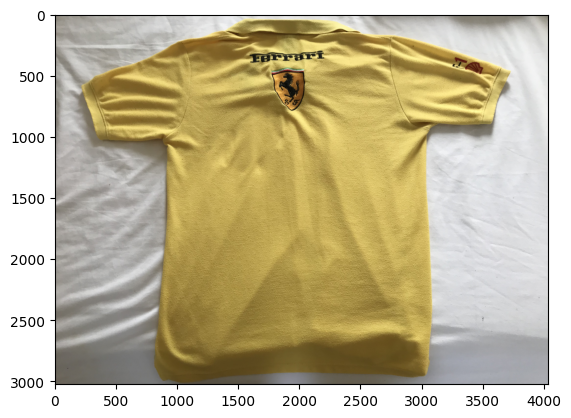

In [ ]:
# Read an image
image_data = cv2.imread('/content/gdrive/MyDrive/Colab Notebooks/t-shirt.png', cv2.IMREAD_UNCHANGED)

# View the image
import matplotlib.pyplot as plt

# Use cv2.cvtColor because OpenCV uses BGR, but matplotlib uses RGB
plt.imshow(cv2.cvtColor(image_data, cv2.COLOR_BGR2RGB))
plt.show()

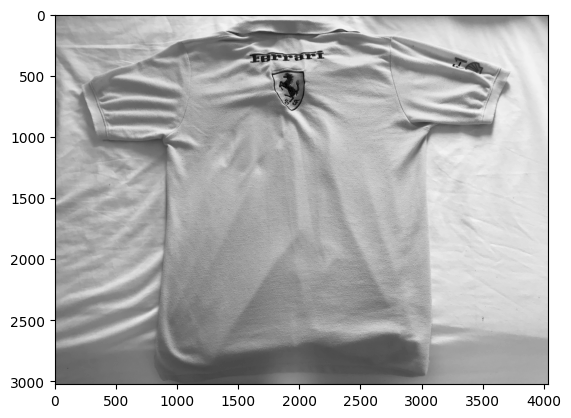

In [ ]:
# Read image as grayscale
image_data = cv2.imread('/content/gdrive/MyDrive/Colab Notebooks/t-shirt.png', cv2.IMREAD_GRAYSCALE)

# View the image
plt.imshow(image_data, cmap='gray')
plt.show()

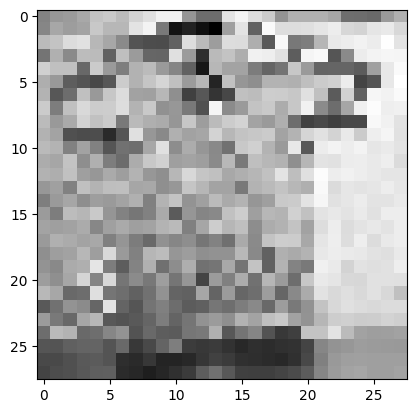

In [ ]:
# Resize to the same size as Fashion MNIST images
image_data = cv2.resize(image_data, (28, 28))

# View the image
plt.imshow(image_data, cmap='gray')
plt.show()

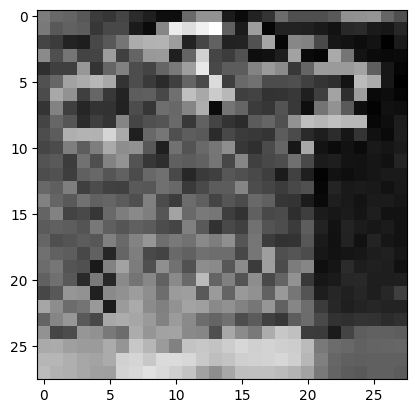

In [ ]:
# Invert image colors (i.e., use same background color (black) as trained images)
image_data = 255 - image_data # subtract all the pixel values from the maximum pixel value (255)

# View the image
plt.imshow(image_data, cmap='gray')
plt.show()

In [ ]:
# Reshape/flatten 28x28 to 784 and scale pixel data (singel image passed as a list of 1 sample)
image_data = (image_data.reshape(1, -1).astype(np.float32) - 127.5) / 127.5

# Predict Model on the Image

The Dense layers learn feature (pixel in this case) values and the correlation between them, why having the correct background color is important. Contrasted to convolutional layers, which are trained to find features on images
(not features as data input nodes, but actual characteristics/traits, such as lines and curves).


In [ ]:
# The subdirectory names are the labels
import os

labels = os.listdir('fashion_mnist_images/train')
print(labels)

['9', '4', '5', '8', '3', '1', '6', '0', '2', '7']


In [ ]:
# Label index to label name relation
fashion_mnist_labels = {0: 'T-shirt/top',
                        1: 'Trouser',
                        2: 'Pullover',
                        3: 'Dress',
                        4: 'Coat',
                        5: 'Sandal',
                        6: 'Shirt',
                        7: 'Sneaker',
                        8: 'Bag',
                        9: 'Ankle boot'}

In [ ]:
# Predict on the image
confidences = model.predict(image_data)

# Get prediction instead of confidence levels from relevant activation (here, softmax)
predictions = model.output_layer_activation.predictions(confidences)

# Get label name from label index (here, single image in the form of a list)
prediction = fashion_mnist_labels[predictions[0]] # predictions[0] ->  returns a list containing a single prediction

print(prediction)

T-shirt/top


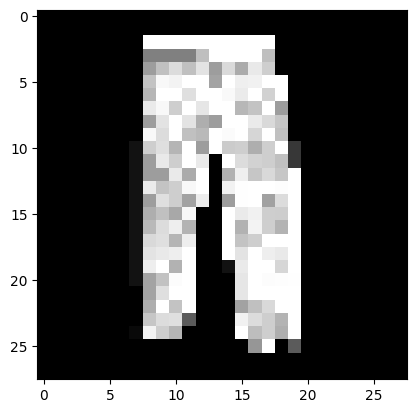

In [63]:
image_data_2 = cv2.imread('/content/gdrive/MyDrive/Colab Notebooks/pants.png', cv2.IMREAD_GRAYSCALE)
image_data_2 = cv2.resize(image_data_2, (28, 28))
image_data_2 = 255 - image_data_2

# View the image
plt.imshow(image_data_2, cmap='gray')
plt.show()

In [64]:
image_data_2 = (image_data_2.reshape(1, -1).astype(np.float32) - 127.5) / 127.5

In [65]:
# Predict on the image
confidences_2 = model.predict(image_data_2)

# Get prediction instead of confidence levels from relevant activation (here, softmax)
predictions_2 = model.output_layer_activation.predictions(confidences_2)

# Get label name from label index (here, single image in the form of a list)
predictions_2 = fashion_mnist_labels[predictions_2[0]] # predictions[0] ->  returns a list containing a single prediction

print(predictions_2)

Trouser
